# L14a Example: Memorizing SPY with a HiPPO-LegS SSM
This example makes every piece of the L14a lecture concrete on a real financial sequence. We fit a SISO HiPPO-LegS structured state space model to the daily log-growth rate of the S&P 500 ETF (ticker SPY) over 2014-2024 and evaluate it on the held-out 2025 sequence. The training task is _memorization_: we ask the model to reconstruct its own input from the hidden state, so the target at time $t$ equals the input at time $t$. This tests whether the HiPPO-LegS basis, with $h$ polynomial coefficients, carries enough information about the past to recover the current sample.

> __Problem statement.__ We have one scalar sequence per year: daily log-growth rates $g_{t} = (1/\Delta t)\log(P_{t}/P_{t-1})$ with $\Delta t = 1/252$. We fit the readout $\bar{\mathbf{C}}$ by closed-form ridge regression on 2014-2024 hidden states against the input sequence itself, evaluate the in-sample fit, then apply the same $\bar{\mathbf{C}}$ to the 2025 input to measure out-of-sample reconstruction quality. We also sweep the hidden dimension $h$ to show how reconstruction fidelity scales with the amount of memory.

With that problem statement fixed, we lay out what a student should be able to do after working through the notebook.

> __Learning Objectives:__ After working through this notebook you should be able to:
>
> * __Build a SISO HiPPO-LegS model and run it forward on real data:__ Construct the LegS state and input matrices, discretize them bilinearly at the daily time step, and roll out the discrete-time recursion to produce the hidden-state matrix for a given input sequence.
> * __Fit the readout by closed-form ridge regression:__ Assemble the hidden-state matrix and target vector for the memorize task, solve the ridge normal equations in closed form, and verify that the resulting in-sample fit is strong.
> * __Evaluate out-of-sample and explain the hidden-dimension dependence:__ Apply the trained readout to a 2025 holdout sequence, compare the reconstruction distribution and autocorrelation to the observed sequence, and explain why reconstruction correlation improves as the hidden dimension grows.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the [`Include.jl`](Include.jl) file, which sets paths, loads external packages, sets the random seed, and pulls in local source files from `src/`:
* [`src/Types.jl`](src/Types.jl) defines the [`MySisoLegSHippoModel`](src/Types.jl) struct.
* [`src/Compute.jl`](src/Compute.jl) defines [`build_legS_matrices`](src/Compute.jl), [`discretize`](src/Compute.jl), [`build`](src/Compute.jl), [`rollout`](src/Compute.jl), [`solve`](src/Compute.jl), [`fit_C!`](src/Compute.jl), [`predict`](src/Compute.jl), and [`log_growth_rate`](src/Compute.jl).
* [`src/Files.jl`](src/Files.jl) defines [`load_ohlc_dataset`](src/Files.jl), [`save_model_checkpoint`](src/Files.jl), and [`load_model_checkpoint`](src/Files.jl).

In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14a`


### Constants
We fix the ticker, the sampling step, the hidden dimension, and the ridge penalty up front so every cell below reads from a single set of knobs.

* `TICKER::String` is the ticker symbol we pull from the dataset (SPY, the S&P 500 ETF).
* `Δt::Float64` is the trading-day time step, $\Delta t = 1/252$ years.
* `H_DEFAULT::Int` is the hidden dimension used for the main run; the sweep at the end varies this.
* `RIDGE_λ::Float64` is the ridge regularization for the closed-form $\bar{\mathbf{C}}$ solve.
* `H_SWEEP::Vector{Int}` is the list of hidden dimensions used in the final sweep.
* `WARMUP_STEPS::Int` is the number of steps of the out-of-sample rollout we drop so the hidden state can forget $\mathbf{x}_{0} = \mathbf{0}$.
* `CHECKPOINT_PATH::String` is where we save the canonical trained model.

In [2]:
TICKER          = "SPY"
Δt              = 1.0 / 252.0
H_DEFAULT       = 128
RIDGE_λ         = 1.0e-4
H_SWEEP         = [2, 4, 8, 16, 32, 64, 128]
WARMUP_STEPS    = 25
CHECKPOINT_PATH = joinpath(_PATH_TO_DATA, "HiPPO-$(TICKER)-N$(H_DEFAULT).jld2");

___

## Task 1: Load SPY and compute log-growth rates
The first task is to load the SPY close-price series for 2014-2024 (training) and 2025 (held out), and convert each into a log-growth-rate sequence.

> __Data.__ Both files in [`data/`](data) are Polygon.io daily OHLC bars for S&P 500 constituents and a few ETFs. The training file `SPY-Daily-OHLC-2014-2024.jld2` covers 2014-01-03 through 2024-12-31 ($T_{\text{train}} \approx 2767$ bars); the testing file `SPY-Daily-OHLC-2025.jld2` covers 2025 year-to-date ($T_{\text{test}} \approx 250$ bars). 
>
> The wrapper [`load_ohlc_dataset(path)`](src/Files.jl) returns a [`Dict`](https://docs.julialang.org/en/v1/base/collections/#Base.Dict)`{String, `[`DataFrame`](https://dataframes.juliadata.org/stable/lib/types/#DataFrames.DataFrame)`}` keyed by ticker, and we pull the SPY `close` column from each.

__Variables:__
* `spy_train::`[`DataFrame`](https://dataframes.juliadata.org/stable/lib/types/#DataFrames.DataFrame) is the training OHLC data for SPY.
* `spy_test::`[`DataFrame`](https://dataframes.juliadata.org/stable/lib/types/#DataFrames.DataFrame) is the 2025 holdout OHLC data for SPY.
* `u_train::Vector{Float64}` is the training log-growth rate sequence, length $T_{\text{train}} - 1$.
* `u_test::Vector{Float64}` is the holdout log-growth rate sequence, length $T_{\text{test}} - 1$.

In [3]:
# load the raw OHLC data
spy_train = load_ohlc_dataset(joinpath(_PATH_TO_DATA, "SPY-Daily-OHLC-2014-2024.jld2"))[TICKER];
spy_test  = load_ohlc_dataset(joinpath(_PATH_TO_DATA, "SPY-Daily-OHLC-2025.jld2"))[TICKER];

# compute the log-growth-rate sequences for training and testing
u_train = log_growth_rate(spy_train.close; Δt = Δt);
u_test  = log_growth_rate(spy_test.close;  Δt = Δt);

# Output - 
@info "SPY loaded" train_rows=nrow(spy_train) test_rows=nrow(spy_test) T_train=length(u_train) T_test=length(u_test)
@info "log-growth-rate summary (annualized)" train_mean=round(mean(u_train), digits=3) train_std=round(std(u_train), digits=3) test_mean=round(mean(u_test), digits=3) test_std=round(std(u_test), digits=3);

┌ Info: SPY loaded
│   train_rows = 2767
│   test_rows = 250
│   T_train = 2766
│   T_test = 249
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X46sZmlsZQ==.jl:10
┌ Info: log-growth-rate summary (annualized)
│   train_mean = 0.106
│   train_std = 2.741
│   test_mean = 0.156
│   test_std = 3.073
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X46sZmlsZQ==.jl:11


### Visualize the training signal
Let's look at the training log-growth rate sequence we are going to memorize.

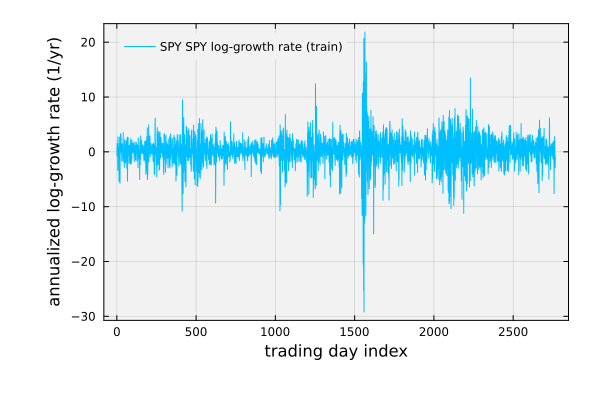

In [4]:
let
    plot(u_train;
        label = "SPY $(TICKER) log-growth rate (train)",
        xlabel = "trading day index",
        ylabel = "annualized log-growth rate (1/yr)",
        lw = 1.0, c = :deepskyblue,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent,
        left_margin = 12Plots.mm, bottom_margin = 10Plots.mm, right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

___

## Task 2: Build and train the HiPPO-LegS model
In this task, we build a SISO HiPPO-LegS SSM with hidden dimension `H_DEFAULT = 128`, sanity-checks the untrained rollout, and then fit the output matrix $\bar{\mathbf{C}}$ by closed-form ridge regression on the 2014-2024 training sequence.

We start by constructing the model, checking the eigenspectrum of $\mathbf{A}$ and $\bar{\mathbf{A}}$ to confirm stability, and running the untrained model forward on the training input.

> __What does untrained mean?__ 
> 
> The HiPPO construction fixes $(\mathbf{A}, \mathbf{B})$ analytically; the only learned object is $\bar{\mathbf{C}}$. When we [`build`](src/Compute.jl) a fresh model we set $\bar{\mathbf{C}} = \mathbf{0}$, so [`solve(model, u)`](src/Compute.jl) returns hidden states $\mathbf{X}$ populated by the LegS filter but an output $\hat{y} = \bar{\mathbf{C}}\mathbf{X}^{\top} = \mathbf{0}$. The point of "untrained" here is to confirm the hidden-state rollout is numerically stable before we fit anything.

We represent the HiPPO-LegS model with the type `model::`[`MySisoLegSHippoModel`](src/Types.jl), which is the constructed LegS model at `h = H_DEFAULT`; downstream cells reassign it after fitting.

In [5]:
model = build(MySisoLegSHippoModel; h = H_DEFAULT, Δt = Δt);
@info "continuous A eigenvalues (should be real, negative)" first_three=round.(real.(eigvals(model.A)[1:3]), digits=3) last_three=round.(real.(eigvals(model.A)[end-2:end]), digits=3)
@info "discrete Ā spectral radius (should be < 1)" ρ_Ā=round(maximum(abs, eigvals(model.Ā)), digits=6);

┌ Info: continuous A eigenvalues (should be real, negative)
│   first_three = [-129.0, -128.0, -127.0]
│   last_three = [-4.0, -3.0, -2.0]
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X53sZmlsZQ==.jl:2
┌ Info: discrete Ā spectral radius (should be < 1)
│   ρ_Ā = 0.992095
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X53sZmlsZQ==.jl:3


Next, we sanity-check the untrained rollout by computing the hidden-state matrix from the input `u_train` vector and confirming that the output is identically zero before any fitting has happened; the diagnostic values are logged with [`@info`](https://docs.julialang.org/en/v1/stdlib/Logging/#Logging.@info) and kept local to the cell.

In [6]:
let
    (X, y) = solve(model, u_train)
    @info "untrained rollout" X_shape=size(X) X_colmax=round(maximum(abs, X), digits=3) y_is_zero=all(iszero, y)
end;

┌ Info: untrained rollout
│   X_shape = (2766, 128)
│   X_colmax = 1.197
│   y_is_zero = true
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X54sZmlsZQ==.jl:3


### Fit the output $\bar{\mathbf{C}}$ by closed-form ridge regression
With the untrained model in hand, we fit the readout row vector $\bar{\mathbf{C}}\in\mathbb{R}^{1\times h}$ on the training sequence. For the memorize task we set the target equal to the input, $y_{t} = u_{t}$, and solve the normal equations:
$$
\hat{\bar{\mathbf{C}}}^{\top} = \left(\mathbf{X}^{\top}\mathbf{X} + \lambda\mathbf{I}\right)^{-1}\mathbf{X}^{\top}\mathbf{u}
$$
The helper [`fit_C!(model, u, y; λ)`](src/Compute.jl) does this in place and returns the updated model. 

If a cached checkpoint exists at `CHECKPOINT_PATH` we load it via [`load_model_checkpoint`](src/Files.jl); otherwise we fit fresh and write the result with [`save_model_checkpoint`](src/Files.jl). This lets a student re-run the notebook later without recomputing.

In [7]:
if isfile(CHECKPOINT_PATH)
    model = load_model_checkpoint(CHECKPOINT_PATH)
    @info "loaded cached checkpoint" path=CHECKPOINT_PATH h=model.h
else
    fit_C!(model, u_train, u_train; λ = RIDGE_λ)
    save_model_checkpoint(CHECKPOINT_PATH, model)
    @info "fit Ĉ and cached checkpoint" path=CHECKPOINT_PATH h=model.h λ=RIDGE_λ
end;

┌ Info: loaded cached checkpoint
│   path = /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14a/data/HiPPO-SPY-N128.jld2
│   h = 128
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X56sZmlsZQ==.jl:3


### In-sample reconstruction
With $\bar{\mathbf{C}}$ fit, let's resolve the model using the [`solve(model, u_train)` function](src/Compute.jl) to get the trained output $\hat{y}_{\text{train}}$ and compare it to the input.

The cell below stores the result in `ŷ_train::Vector{Float64}` for use by the plot cells that follow; the Pearson correlation and mean-squared error are computed as local diagnostics and reported with [`@info`](https://docs.julialang.org/en/v1/stdlib/Logging/#Logging.@info).

In [8]:
ŷ_train = let
    (_, yhat) = solve(model, u_train)
    ρ = cor(u_train, yhat)
    mse = mean((u_train .- yhat).^2)
    @info "in-sample memorize fit" h=model.h ρ=round(ρ, digits=4) mse=round(mse, digits=6)
    yhat
end;

┌ Info: in-sample memorize fit
│   h = 128
│   ρ = 1.0
│   mse = 0.0
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X61sZmlsZQ==.jl:5


### Visualize the fit
Time-series overlay (left) and scatter of trained output vs. observed (right). A perfect memorize would put the scatter on the 45° line.

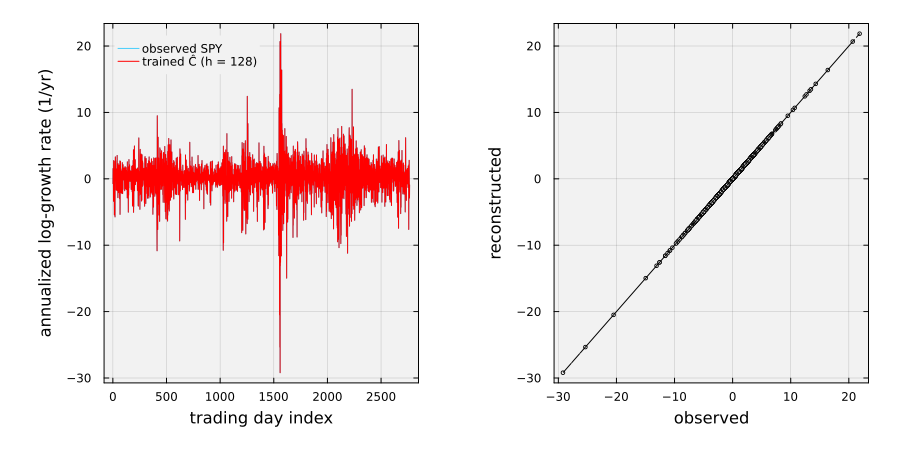

In [9]:
let
    l = @layout [a b]
    p1 = plot(u_train;
        label = "observed $(TICKER)",
        xlabel = "trading day index", ylabel = "annualized log-growth rate (1/yr)",
        lw = 1.0, c = :deepskyblue, alpha = 0.75,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p1, ŷ_train;
        label = "trained Ĉ (h = $(model.h))",
        lw = 1.0, c = :red)

    p2 = scatter(u_train, ŷ_train;
        label = "",
        xlabel = "observed", ylabel = "reconstructed",
        c = :white, msc = :black, markersize = 2,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box)
    plot!(p2, u_train, u_train; label = "", c = :black, lw = 1, ls = :dash)

    plot(p1, p2; layout = l, size = (900, 460), left_margin = 12Plots.mm, bottom_margin = 10Plots.mm, right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Distribution and autocorrelation
Two diagnostics beyond point-wise fit: the marginal distribution of $\hat{y}$ should match that of $u$, and the autocorrelation structure should be preserved.

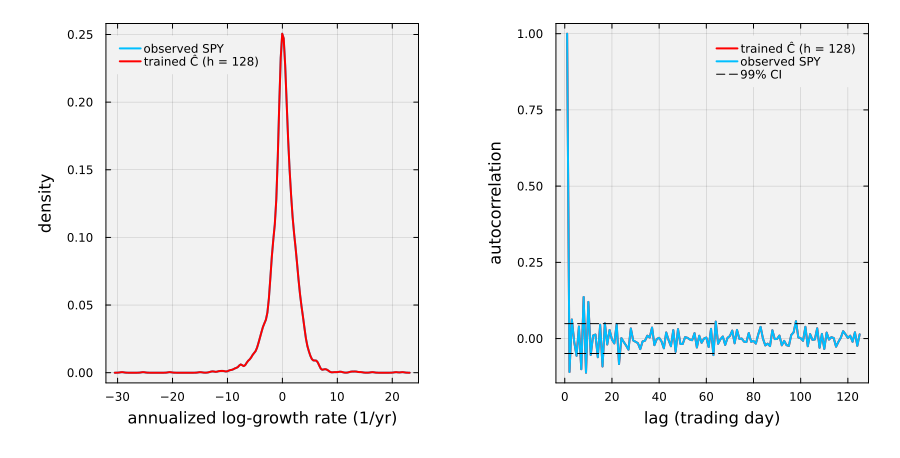

In [10]:
let

    # initialize -
    max_number_of_steps_x = 125;
    l = @layout [a b] # make a 1 x 2 grid of subplots
    
    # Left subplot: density of the observed and reconstructed sequences.
    p1 = density(u_train; label = "observed $(TICKER)",
        lw = 2, c = :deepskyblue,
        xlabel = "annualized log-growth rate (1/yr)", ylabel = "density",
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend=:topleft)
    density!(p1, ŷ_train; label = "trained Ĉ (h = $(model.h))", lw = 2, c = :red)

    # Right subplot: autocorrelation of the observed and reconstructed sequences.
    n_lag = max_number_of_steps_x;
    lags = 0:(n_lag - 1);
    p2 = plot(autocor(ŷ_train, collect(lags)); label = "trained Ĉ (h = $(model.h))", lw = 2, c = :red)
    plot!(p2, autocor(u_train, collect(lags)); label = "observed $(TICKER)",
        lw = 2, c = :deepskyblue,
        xlabel = "lag (trading day)", ylabel = "autocorrelation",
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    ci = 2.576 / sqrt(length(ŷ_train)) # 99% confidence interval for zero autocorrelation
    plot!(p2, lags, fill(ci, n_lag); label = "99% CI", lw = 1, c = :black, ls = :dash)
    plot!(p2, lags, fill(-ci, n_lag); label = "", lw = 1, c = :black, ls = :dash)

    # make the 1 x 2 grid of subplots with shared margins. 
    plot(p1, p2; layout = l, size = (900, 460), 
        left_margin = 12Plots.mm, 
        bottom_margin = 10Plots.mm, 
        right_margin = 6Plots.mm, 
        top_margin = 4Plots.mm)
end

___

## Task 3: Evaluate out-of-sample and sweep the hidden dimension
In this task, we use the model trained on 2014 - 2024 data to simulate the 2025 holdout sequence and then we sweep the hidden state dimension to show how reconstruction fidelity scales with the amount of memory available to the filter.

We apply the same trained $\bar{\mathbf{C}}$ to the 2025 holdout input and measure reconstruction quality. We use [`predict(model, u_test; warmup = WARMUP_STEPS)`](src/Compute.jl) which rolls out on the new input starting from $\mathbf{x}_{0} = \mathbf{0}$ and drops the first `WARMUP_STEPS` samples so the hidden state has time to forget the initial condition.

> __What we expect.__ Because $\bar{\mathbf{C}}$ decodes "current value" from the LegS polynomial coefficients, and the LegS basis geometry does not depend on the training input, the OOS reconstruction correlation should be close to the in-sample value. A large gap would indicate that the training fit was exploiting training-specific correlations rather than capturing the decoder.

The cell below stores `ŷ_test::Vector{Float64}` and the aligned target `u_test_eval::Vector{Float64}` for the plot cell that follows; the out-of-sample correlation and mean-squared error are computed as local diagnostics and reported with [`@info`](https://docs.julialang.org/en/v1/stdlib/Logging/#Logging.@info).

In [11]:
ŷ_test, u_test_eval = let
    (_, yhat) = predict(model, u_test; warmup = WARMUP_STEPS)
    u_eval = u_test[(WARMUP_STEPS + 1):end]
    ρ = cor(u_eval, yhat)
    mse = mean((u_eval .- yhat).^2)
    @info "out-of-sample 2025 reconstruction" h=model.h ρ=round(ρ, digits=4) mse=round(mse, digits=6) T_eval=length(yhat)
    yhat, u_eval
end;

┌ Info: out-of-sample 2025 reconstruction
│   h = 128
│   ρ = 1.0
│   mse = 0.0
│   T_eval = 224
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y120sZmlsZQ==.jl:6


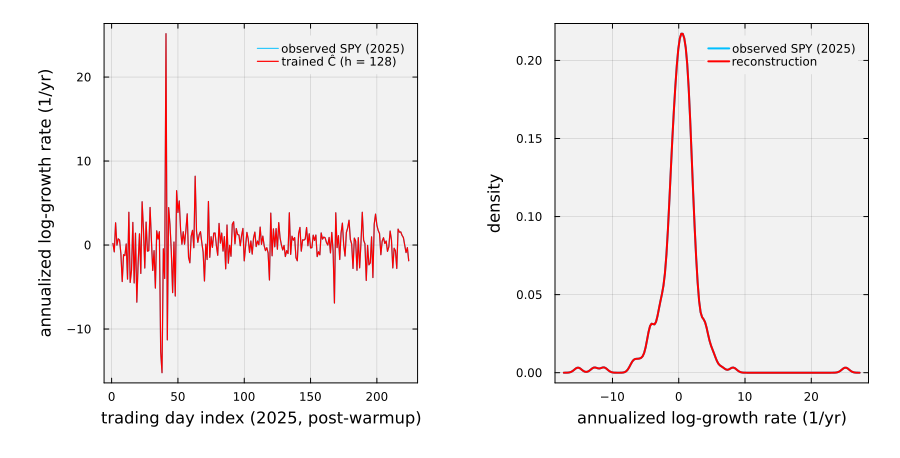

In [12]:
let
    l = @layout [a b]
    p1 = plot(u_test_eval;
        label = "observed $(TICKER) (2025)",
        xlabel = "trading day index (2025, post-warmup)", ylabel = "annualized log-growth rate (1/yr)",
        lw = 1.2, c = :deepskyblue, alpha = 0.8,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p1, ŷ_test;
        label = "trained Ĉ (h = $(model.h))", lw = 1.2, c = :red)

    p2 = density(u_test_eval; label = "observed $(TICKER) (2025)",
        lw = 2, c = :deepskyblue,
        xlabel = "annualized log-growth rate (1/yr)", ylabel = "density",
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    density!(p2, ŷ_test; label = "reconstruction", lw = 2, c = :red)

    plot(p1, p2; layout = l, size = (900, 460), left_margin = 12Plots.mm, bottom_margin = 10Plots.mm, right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Hidden-dimension sweep
The hidden dimension $h$ sets the order of the polynomial approximation the LegS basis can represent. Small $h$ underfits the high-frequency content of the log-growth-rate series; large $h$ should approach perfect reconstruction. 

We repeat the build-fit-evaluate cycle for `H_SWEEP` $= [2, 4, 8, \ldots, 128]$ and collect the in-sample and out-of-sample correlations. We expect reconstruction correlation to climb monotonically from near zero at $h = 2$ to essentially one by $h = 64$, with train and test tracking each other because the decoder $\bar{\mathbf{C}}$ depends on the basis geometry rather than on the specific input distribution.

We store the results in a `sweep_df::`[`DataFrame`](https://dataframes.juliadata.org/stable/lib/types/#DataFrames.DataFrame) with one row per hidden dimension with columns `h`, `ρ_train`, `mse_train`, `ρ_test`, `mse_test`.

In [13]:
sweep_df = let
    df = DataFrame(h = Int[], ρ_train = Float64[], mse_train = Float64[], ρ_test = Float64[], mse_test = Float64[])
    for h in H_SWEEP
        m = build(MySisoLegSHippoModel; h = h, Δt = Δt)
        fit_C!(m, u_train, u_train; λ = RIDGE_λ)

        (_, yhat_tr) = solve(m, u_train)
        ρ_tr  = cor(u_train, yhat_tr)
        mse_tr = mean((u_train .- yhat_tr).^2)

        (_, yhat_te) = predict(m, u_test; warmup = WARMUP_STEPS)
        u_te_eval = u_test[(WARMUP_STEPS + 1):end]
        ρ_te  = cor(u_te_eval, yhat_te)
        mse_te = mean((u_te_eval .- yhat_te).^2)

        push!(df, (h, ρ_tr, mse_tr, ρ_te, mse_te))
    end
    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])
    df
end;

 ------- --------- ----------- --------- -----------
      h   ρ_train   mse_train    ρ_test    mse_test 
  Int64   Float64     Float64   Float64     Float64 
 ------- --------- ----------- --------- -----------
      2    0.2047       7.199     0.216       9.542
      4    0.3299         6.7    0.3392       8.847
      8    0.5478       5.257    0.5681       6.848
     16    0.8409         2.2    0.8447       2.858
     32    0.9944     0.08407    0.9947      0.1062
     64       1.0    2.706e-7       1.0     3.39e-7
    128       1.0   1.242e-11       1.0   2.001e-11
 ------- --------- ----------- --------- -----------


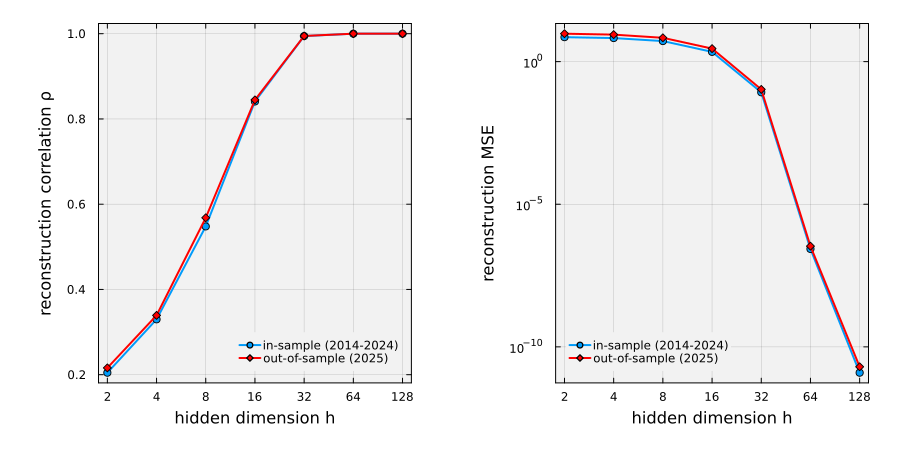

In [15]:
let

    # Left subplot: in-sample and out-of-sample reconstruction correlation vs hidden dimension.
    p1 = plot(sweep_df.h, sweep_df.ρ_train;
        label = "in-sample (2014-2024)", lw = 2, marker = :circle,
        xlabel = "hidden dimension h", ylabel = "reconstruction correlation ρ",
        xscale = :log2, xticks = (H_SWEEP, string.(H_SWEEP)),
        legend = :bottomright,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p1, sweep_df.h, sweep_df.ρ_test;
        label = "out-of-sample (2025)", lw = 2, marker = :diamond, c = :red)

    # Right subplot: in-sample and out-of-sample reconstruction MSE vs hidden dimension.
    p2 = plot(sweep_df.h, sweep_df.mse_train;
        label = "in-sample (2014-2024)", lw = 2, marker = :circle,
        xlabel = "hidden dimension h", ylabel = "reconstruction MSE",
        xscale = :log2, xticks = (H_SWEEP, string.(H_SWEEP)),
        yscale = :log10, legend = :bottomleft,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p2, sweep_df.h, sweep_df.mse_test;
        label = "out-of-sample (2025)", lw = 2, marker = :diamond, c = :red)

    # make a 1 x 2 grid of subplots with shared margins.
    plot(p1, p2; layout = (1, 2), size = (900, 460), 
        left_margin = 12Plots.mm, 
        bottom_margin = 10Plots.mm, 
        right_margin = 6Plots.mm, 
        top_margin = 4Plots.mm);
end

___

## Summary
Training a SISO HiPPO-LegS SSM on 2014-2024 SPY log-growth rates and evaluating on 2025 gives essentially perfect reconstruction once the hidden dimension crosses the bandwidth of the signal, with in-sample and out-of-sample correlations tracking each other at every scale we swept. The entire fit reduces to a closed-form ridge regression on the rolled-out hidden states, replacing what would otherwise be a multi-minute SGD loop with a sub-second linear solve.

> __Key Takeaways:__
>
> * **Reconstruction fidelity scales with the hidden dimension:** The sweep shows correlation climbing from about one-fifth at the smallest basis to essentially one once the basis is large enough, while reconstruction error drops by roughly eleven orders of magnitude across the same range. Each extra basis dimension captures one more mode of variation in the signal, and the LegS basis approaches the full bandwidth of the log-growth-rate series as the hidden dimension grows.
> * **Out-of-sample reconstruction tracks in-sample:** At every hidden dimension in the sweep the 2014-2024 and 2025 correlations sit on top of each other. The trained readout decodes the current-input component from the basis geometry rather than from the specific training distribution, so the same readout generalizes cleanly to a disjoint time window.
> * **Training is a single small linear solve, not an SGD loop:** Fitting the readout reduces to a dense ridge regression whose size is set by the hidden dimension rather than by the sequence length, so it runs in a fraction of a second on CPU. This is the direct computational payoff of freezing the LegS state and input matrices at their HiPPO-initialized values.

In [L14c](../L14c) we relax the SISO assumption and the memorize target: multi-input/multi-output SSMs let us stack vector inputs, and a short-horizon forecasting target turns the same machinery into a predictive model rather than a reconstruction one.

___